# saspy — quickstart

The SAS reservoir is a linear recurrence whose coefficients depend on the input:

$$s_t = P(z_t)\,s_{t-1} + Q(z_t)$$

`P` and `Q` are built from two independent choices:

- a **feature** map on the compact domain $[-1, 1]$ — `Cheb` (Chebyshev polynomials) or `Trig` (random cosines);
- a **structure** for the state matrix — `Diagonal`, `Block`, `Sparse` or `LowRank`.

`SASModel` wires an input projection to a `(P, Q)` pair; `SASForecaster` runs the
scan and fits a ridge readout on top of the states.

This notebook forecasts the Lorenz attractor. It needs `matplotlib` on top of the
package itself:

```
pip install -e ".[examples]"
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from saspy import (SASForecaster, SASModel, Cheb,
                   DiagonalP, DiagonalQ, LowRankP, LowRankQ)


def lorenz(n, dt=0.01, sigma=10.0, rho=28.0, beta=8 / 3, u0=(1.0, 1.0, 1.0)):
    def f(u):
        x, y, z = u
        return np.array([sigma * (y - x), x * (rho - z) - y, x * y - beta * z])
    u, out = np.array(u0, float), np.empty((n, 3))
    for t in range(n):
        k1 = f(u); k2 = f(u + dt / 2 * k1); k3 = f(u + dt / 2 * k2); k4 = f(u + dt * k3)
        u = u + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        out[t] = u
    return out


# Drop the transient, then map each channel into [-0.95, 0.95]: the reservoir
# lives on [-1, 1], and the margin leaves head-room for the test range.
data   = lorenz(11_000)[1000:]
lo, hi = data.min(0), data.max(0)
data   = 0.95 * (2 * (data - lo) / (hi - lo) - 1)

X_train, X_test = data[:8000], data[8000:]
X_train.shape, X_test.shape

((8000, 3), (2000, 3))

## A first model

`DiagonalP` gives one scalar eigenvalue per unit — the cheapest structure, `O(N)`
per step. Chebyshev features of degree 3 modulate it with the input.

`SASModel(..., d=3)` builds a random projection from the 3 Lorenz channels to the
`N` unit drivers. Contractivity is enforced at initialisation, so nothing here
needs a spectral-radius search.

In [2]:
N = 300

model = SASModel(
    DiagonalP(N, feature=Cheb(degree=3)),
    DiagonalQ(N, feature=Cheb(degree=3)),
    d=3, density=0.3,
)
model

SASModel(
  proj=W_in(d=3, density=0.3),
  basis_p=DiagonalP(n=300, feature=Cheb(degree=3, cross_input=True), sn=0.9),
  basis_q=DiagonalQ(n=300, feature=Cheb(degree=3, cross_input=True), sn=0.9)
)

## Teacher-forced forecasting

In `direct` mode one ridge readout is fitted per horizon and `predict(h)` is a
single linear map — no reservoir advance. `update(x)` feeds the *observed* value,
so the reservoir stays on the true trajectory.

In [3]:
fc = SASForecaster(model, washout=200, mode='direct', seed=0)
fc.fit(X_train, horizons=[1, 10], context=X_train)

pred = {h: np.empty_like(X_test) for h in (1, 10)}
for t, x in enumerate(X_test):
    for h in (1, 10):
        pred[h][t] = fc.predict(h)
    fc.update(x)

for h in (1, 10):
    err = np.sqrt(((pred[h] - X_test) ** 2).mean()) / X_test.std()
    print(f"h={h:>2}  NRMSE = {err:.3g}")

h= 1  NRMSE = 6.06e-06
h=10  NRMSE = 0.632


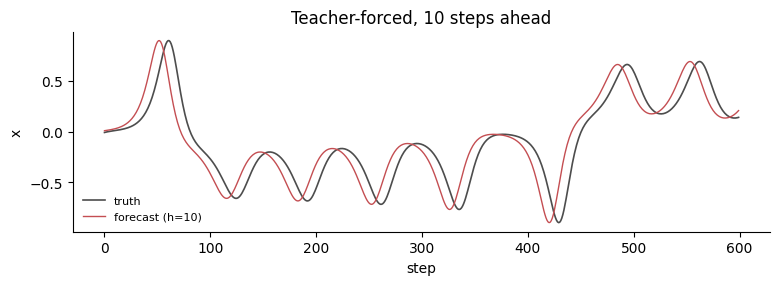

In [4]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(X_test[:600, 0], lw=1.2, color='0.3', label='truth')
ax.plot(pred[10][:600, 0], lw=1.0, color='#C44E52', label='forecast (h=10)')
ax.set(xlabel='step', ylabel='x', title='Teacher-forced, 10 steps ahead')
ax.legend(frameon=False, fontsize=8)
ax.spines[['right', 'top']].set_visible(False)
plt.show()

## Autonomous rollout

One-step-ahead is nearly exact, but the direct readout at h=10 already lags the
signal: a separate linear map per horizon has to encode the whole 10-step flow at
once. Iterating the one-step model instead does much better.

`autoreg` mode fits only the one-step readout; feeding each prediction back as
the next input turns the model into a free-running surrogate of the dynamics.
`clip_output=True` clamps the fed-back value to `[-1, 1]`, which keeps the closed
loop inside the domain the reservoir was calibrated for.

The usual score is the **valid prediction time** (VPT): the number of steps before
the normalised error crosses 0.4, expressed in Lyapunov times. One Lyapunov time
of this Lorenz discretisation is about 110 steps.

In [5]:
LYAP = 110   # steps per Lyapunov time at dt = 0.01


def rollout(model, n_steps, seed=0):
    fc = SASForecaster(model, washout=200, mode='autoreg', clip_output=True, seed=seed)
    fc.fit(X_train, horizons=[1], context=X_train)
    out = np.empty((n_steps, X_train.shape[1]))
    for t in range(n_steps):
        out[t] = fc.predict(1)
        fc.update(out[t])           # own prediction back in — no observation
    return out


def vpt(pred, truth, eps=0.4):
    err = np.sqrt(((pred - truth) ** 2).mean(1)) / truth.std(0).mean()
    over = np.flatnonzero(err > eps)
    return (len(err) if over.size == 0 else int(over[0])) / LYAP


free = rollout(model, len(X_test))
print(f"VPT = {vpt(free, X_test):.2f} Lyapunov times")

VPT = 9.19 Lyapunov times


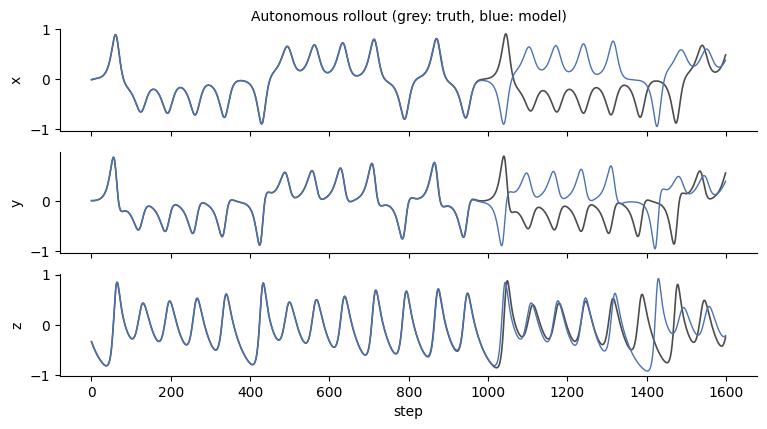

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 4.5), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(X_test[:1600, i], lw=1.2, color='0.3')
    ax.plot(free[:1600, i], lw=1.0, color='#4C72B0')
    ax.set_ylabel('xyz'[i])
    ax.spines[['right', 'top']].set_visible(False)
axes[0].set_title('Autonomous rollout (grey: truth, blue: model)', fontsize=10)
axes[-1].set_xlabel('step')
plt.show()

## Changing the structure

The forecaster does not care which structure produced `P` and `Q`. `LowRankP`
writes the state matrix as a fixed backbone plus `rank` input-driven rank-one
terms, which buys a richer transition than the diagonal at the same state size.
With `alpha_mode='driver'` the number of drivers must equal the rank.

In [7]:
R = 64

lowrank = SASModel(
    LowRankP(N, R, rank=R, feature=Cheb(degree=5), alpha_mode='driver'),
    LowRankQ(N, R, rank=R, feature=Cheb(degree=5), alpha_mode='driver', density_G=0.1),
    d=3,
)

free_lr = rollout(lowrank, len(X_test))
print(f"diagonal  VPT = {vpt(free, X_test):.2f}")
print(f"low-rank  VPT = {vpt(free_lr, X_test):.2f}")

diagonal  VPT = 9.19
low-rank  VPT = 9.15


`SparseP`/`SparseQ` (joint features over all inputs, sparse recurrence) and
`BlockP`/`BlockQ` (rotation blocks, LRU-style) plug in the same way, as does the
`Trig` feature in place of `Cheb`.

## Reservoir states

`transform` returns the raw `(T, N)` state matrix, for a custom readout or for
inspection.

(8000, 300)


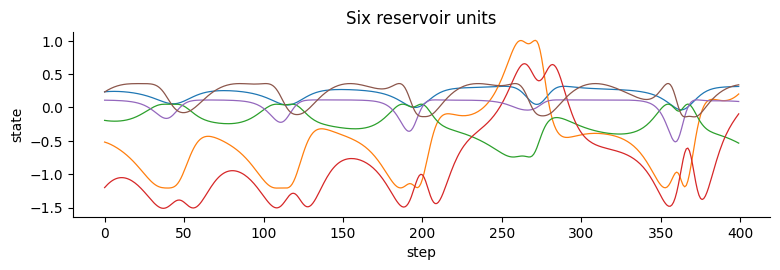

In [8]:
S = fc.transform(X_train, context=X_train)
print(S.shape)

fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot(S[500:900, :6], lw=0.9)
ax.set(xlabel='step', ylabel='state', title='Six reservoir units')
ax.spines[['right', 'top']].set_visible(False)
plt.show()